In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")   # themes: white, dark, ticks
sns.set_palette("deep")      # color themes

In [2]:
df=pd.read_csv('House Price India.csv')

DATA UNDERSTANDING

In [3]:
df.shape

(14620, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [5]:
df.nunique()

id                                       14620
Date                                       241
number of bedrooms                          12
number of bathrooms                         29
living area                                865
lot area                                  7451
number of floors                             6
waterfront present                           2
number of views                              5
condition of the house                       5
grade of the house                          10
Area of the house(excluding basement)      781
Area of the basement                       280
Built Year                                 116
Renovation Year                             68
Postal Code                                 70
Lattitude                                 4662
Longitude                                  716
living_area_renov                          665
lot_area_renov                            6835
Number of schools nearby                     3
Distance from

In [6]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,...,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,6.762821e+09,42604.538646,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,...,1970.926402,90.924008,122033.062244,52.792848,-114.404007,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,6.237575e+03,67.347991,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,...,29.493625,416.216661,19.082418,0.137522,0.141326,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


MISSING VALUES

In [7]:
df.isnull().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

TARGET FEATURE ANALYSIS

<Axes: >

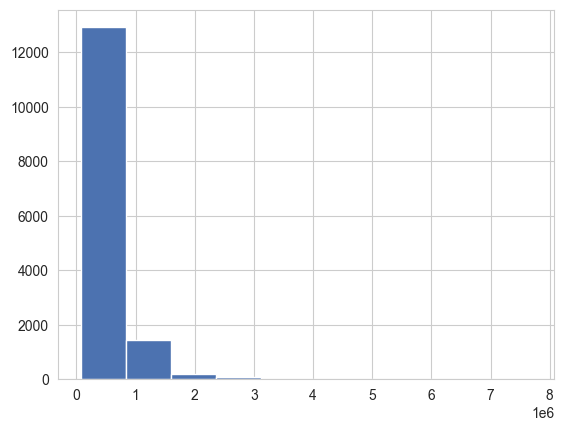

In [8]:
df['Price'].hist()

RIGHT SKEWED SO WE WILL APPLY LOG TRANSFORM

FEATURE RELAYIONSHIPS

In [43]:
corr=df.select_dtypes(include=['number']).corr()*100

corr['Price'].sort_values(ascending=False)

Price                     100.000000
Total Area                 71.216948
grade of the house         67.181438
living_area_renov          58.492446
number of bathrooms        53.173456
number of views            39.597310
number of bedrooms         30.846014
Lattitude                  29.748998
waterfront present         26.368655
number of floors           26.273183
Renovation Year            13.317265
lot area                    8.199200
lot_area_renov              7.553517
Built Year                  5.030711
condition of the house      4.137638
Longitude                   2.441402
Name: Price, dtype: float64

DROP UNWANTED COLN

In [42]:
# df=df.drop(columns=['id','Postal Code','Date'])
df=df.drop(columns=['Number of schools nearby','Distance from the airport'])

FEATURE ENGG : Combined Two Coln to create a new coln with higher corr

In [21]:
df['Total Area']=df['Area of the house(excluding basement)'] + df['Area of the basement']

In [ ]:
(df['Total Area']==df['living area']).value_counts()

df=df.drop(columns=['living area','Area of the house(excluding basement)','Area of the basement'])

True    14620
Name: count, dtype: int64

Multicollinearity Check

In [ ]:
corr=df.select_dtypes(include=['number']).corr()*100
corr

VISUALIZATION

<Axes: xlabel='Longitude', ylabel='Price'>

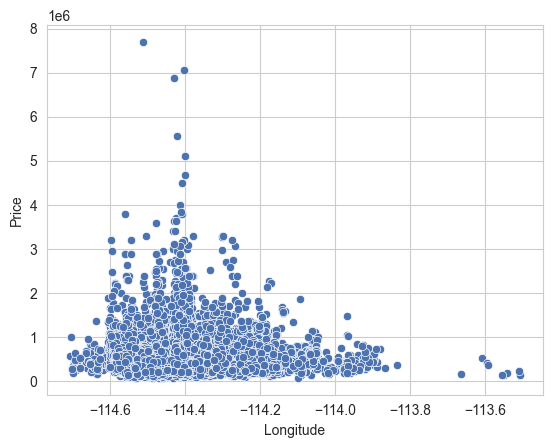

In [53]:
sns.scatterplot(data=df,x='Longitude',y='Price')

FEATURE ENGG for LAT+LONG coln

In [55]:
from sklearn.cluster import KMeans

mean=KMeans(n_clusters=5,random_state=42)

df['location_cluster']=mean.fit_predict(df[['Lattitude', 'Longitude']])

In [59]:
corr=df.select_dtypes(include=['number']).corr()



In [65]:
corr['Price'].sort_values(ascending=False)*100

Price                     100.000000
Total Area                 71.216948
grade of the house         67.181438
living_area_renov          58.492446
number of bathrooms        53.173456
number of views            39.597310
number of bedrooms         30.846014
Lattitude                  29.748998
waterfront present         26.368655
number of floors           26.273183
Renovation Year            13.317265
lot area                    8.199200
lot_area_renov              7.553517
Built Year                  5.030711
condition of the house      4.137638
Longitude                   2.441402
location_cluster           -0.904140
Name: Price, dtype: float64

In [66]:
df.groupby('location_cluster')['Price'].mean()

location_cluster
0    363274.289387
1    750047.070003
2    614753.774593
3    334534.578341
4    573344.778592
Name: Price, dtype: float64